In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
prepared_file_path = r"D:\Data Analytics Project\EduPro_Predictive_Modeling\data\prepared_data\EduPro_Prepared.xlsx"

df = pd.read_excel(
    prepared_file_path,
    sheet_name="Prepared_Data"
)

In [3]:
df.shape

(10000, 29)

In [4]:
df.columns.tolist()

['TransactionID',
 'UserID',
 'CourseID',
 'TransactionDate',
 'Amount',
 'PaymentMethod',
 'TeacherID',
 'UserName',
 'UserAge',
 'UserGender',
 'Email',
 'CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'CoursePrice',
 'CourseDuration',
 'CourseRating',
 'TeacherName',
 'TeacherAge',
 'TeacherGender',
 'Expertise',
 'YearsOfExperience',
 'TeacherRating',
 'TransactionYear',
 'TransactionMonth',
 'TransactionDay',
 'TransactionDayOfWeek',
 'TransactionQuarter']

In [5]:
performance_eda = df.copy()

In [6]:
performance_eda.shape

(10000, 29)

## PART A — Teacher Performance Analysis

In [7]:
teacher_transactions = (
    performance_eda
    .groupby(["TeacherID", "TeacherName"])
    .size()
    .reset_index(name="TransactionCount")
    .sort_values("TransactionCount", ascending=False)
)

teacher_transactions.head(10)                

,TeacherID,TeacherName,TransactionCount
41,TC00042,Yolanda Levine,3061
39,TC00040,Kimberly Miller,3025
30,TC00031,Brenda Mercer,164
27,TC00028,Timothy Bailey,161
57,TC00058,Andrew Anderson,138
32,TC00033,Wesley Garcia,137
26,TC00027,Laurie Michael,133
7,TC00008,Steven Walker,133
55,TC00056,Alexis Everett,123
52,TC00053,Aaron Kirby,120


## Teacher Revenue Performance

In [8]:
teacher_revenue = (
    performance_eda
    .groupby(["TeacherID", "TeacherName"])["Amount"]
    .sum()
    .reset_index(name="TotalRevenue")
    .sort_values("TotalRevenue", ascending=False)
)

teacher_revenue.head(10)

,TeacherID,TeacherName,TotalRevenue
39,TC00040,Kimberly Miller,284933.49
41,TC00042,Yolanda Levine,281719.73
27,TC00028,Timothy Bailey,31102.99
26,TC00027,Laurie Michael,29723.74
17,TC00018,Kari Pierce,18621.84
51,TC00052,Susan Johnson,16773.24
59,TC00060,Benjamin Gray,15537.36
7,TC00008,Steven Walker,11851.45
53,TC00054,Shelby Patrick,11551.14
28,TC00029,David Webb,11323.98


## Combine teacher performance metrics

In [9]:
teacher_performance = (
    performance_eda
    .groupby(
        [
            "TeacherID",
            "TeacherName",
            "Expertise",
            "YearsOfExperience",
            "TeacherRating"
        ]
    )
    .agg(
        TransactionCount=("TransactionID", "count"),
        TotalRevenue=("Amount", "sum"),
        AverageTransactionAmount=("Amount", "mean"),
        CourseCount=("CourseID", "nunique")
    )
    .reset_index()
)

In [10]:
teacher_performance = teacher_performance.sort_values(
    "TotalRevenue",
    ascending=False
)

teacher_performance.head(10)

,TeacherID,TeacherName,Expertise,YearsOfExperience,TeacherRating,TransactionCount,TotalRevenue,AverageTransactionAmount,CourseCount
39,TC00040,Kimberly Miller,Cybersecurity,24,4.58,3025,284933.49,94.192889,55
41,TC00042,Yolanda Levine,Machine Learning,21,4.97,3061,281719.73,92.035194,55
27,TC00028,Timothy Bailey,Business,3,1.06,161,31102.99,193.186273,16
26,TC00027,Laurie Michael,Artificial Intelligence,3,1.55,133,29723.74,223.486767,13
17,TC00018,Kari Pierce,Project Management,11,4.28,93,18621.84,200.234839,8
51,TC00052,Susan Johnson,Business,12,3.43,97,16773.24,172.920000,19
59,TC00060,Benjamin Gray,Project Management,14,3.32,92,15537.36,168.884348,15
7,TC00008,Steven Walker,Data Science,15,3.54,133,11851.45,89.108647,9
53,TC00054,Shelby Patrick,Artificial Intelligence,7,4.28,46,11551.14,251.111739,9
28,TC00029,David Webb,Artificial Intelligence,2,3.10,66,11323.98,171.575455,18


## Top 10 teachers by transactioms

In [11]:
top_teachers_transactions = (
    teacher_performance
    .sort_values("TransactionCount", ascending=False)
    .head(10)
)

top_teachers_transactions

,TeacherID,TeacherName,Expertise,YearsOfExperience,TeacherRating,TransactionCount,TotalRevenue,AverageTransactionAmount,CourseCount
41,TC00042,Yolanda Levine,Machine Learning,21,4.97,3061,281719.73,92.035194,55
39,TC00040,Kimberly Miller,Cybersecurity,24,4.58,3025,284933.49,94.192889,55
30,TC00031,Brenda Mercer,Cybersecurity,1,1.86,164,9226.36,56.258293,15
27,TC00028,Timothy Bailey,Business,3,1.06,161,31102.99,193.186273,16
57,TC00058,Andrew Anderson,Web Development,7,3.71,138,5515.21,39.965290,10
32,TC00033,Wesley Garcia,Design,12,4.04,137,9539.04,69.628029,8
7,TC00008,Steven Walker,Data Science,15,3.54,133,11851.45,89.108647,9
26,TC00027,Laurie Michael,Artificial Intelligence,3,1.55,133,29723.74,223.486767,13
55,TC00056,Alexis Everett,Programming,9,3.95,123,11163.13,90.757154,8
52,TC00053,Aaron Kirby,Marketing,9,4.29,120,2564.97,21.374750,9


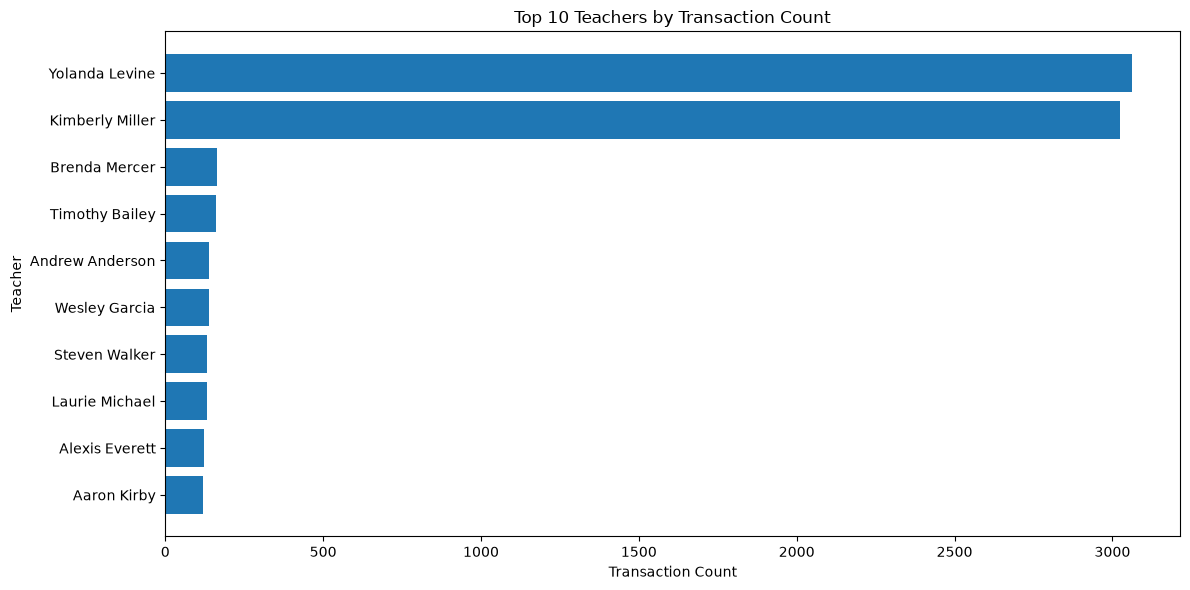

In [12]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_teachers_transactions["TeacherName"],
    top_teachers_transactions["TransactionCount"]
)

plt.title("Top 10 Teachers by Transaction Count")
plt.xlabel("Transaction Count")
plt.ylabel("Teacher")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Top 10 teachers by revenue 

In [13]:
top_teachers_revenue = (
    teacher_performance
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)

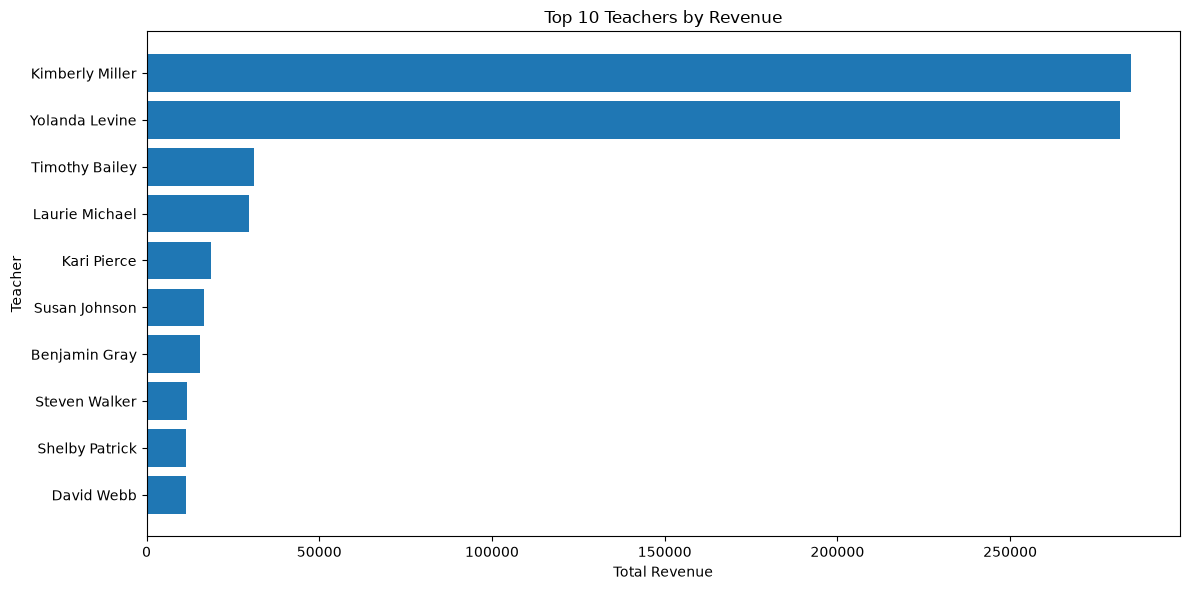

In [14]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_teachers_revenue["TeacherName"],
    top_teachers_revenue["TotalRevenue"]
)

plt.title("Top 10 Teachers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Teacher")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Teacher rating vs transaction performance


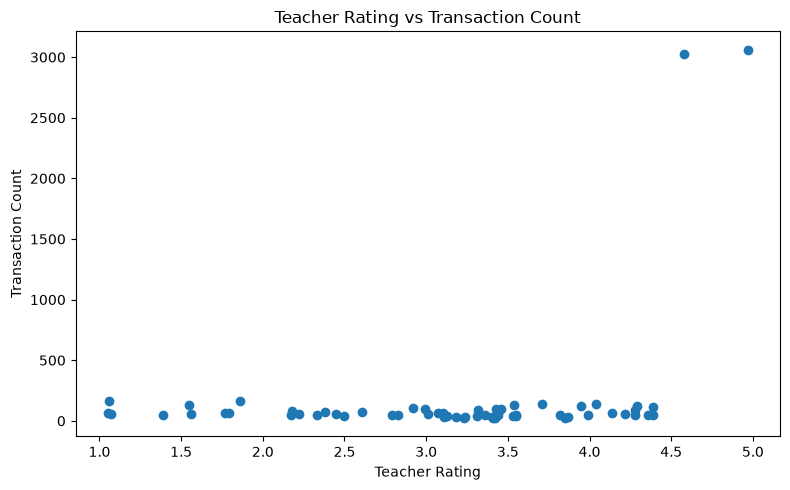

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    teacher_performance["TeacherRating"],
    teacher_performance["TransactionCount"]
)

plt.title("Teacher Rating vs Transaction Count")
plt.xlabel("Teacher Rating")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

## Teacher rating vs revenue 


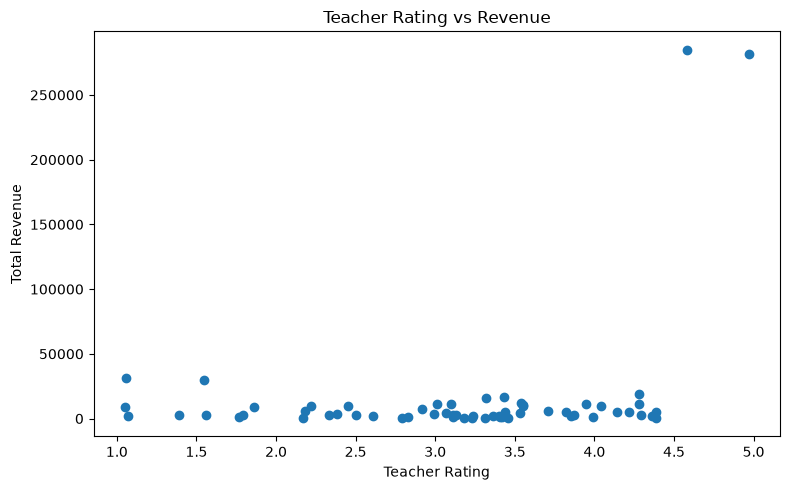

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    teacher_performance["TeacherRating"],
    teacher_performance["TotalRevenue"]
)

plt.title("Teacher Rating vs Revenue")
plt.xlabel("Teacher Rating")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## Teacher experience vs performance

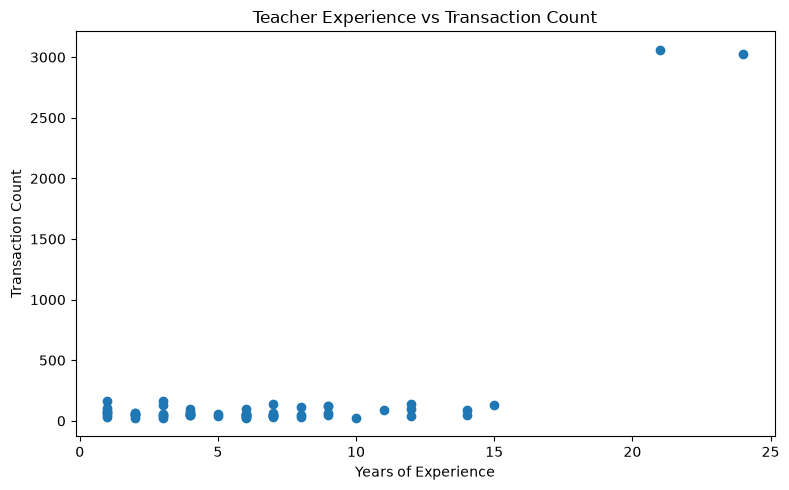

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    teacher_performance["YearsOfExperience"],
    teacher_performance["TransactionCount"]
)

plt.title("Teacher Experience vs Transaction Count")
plt.xlabel("Years of Experience")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

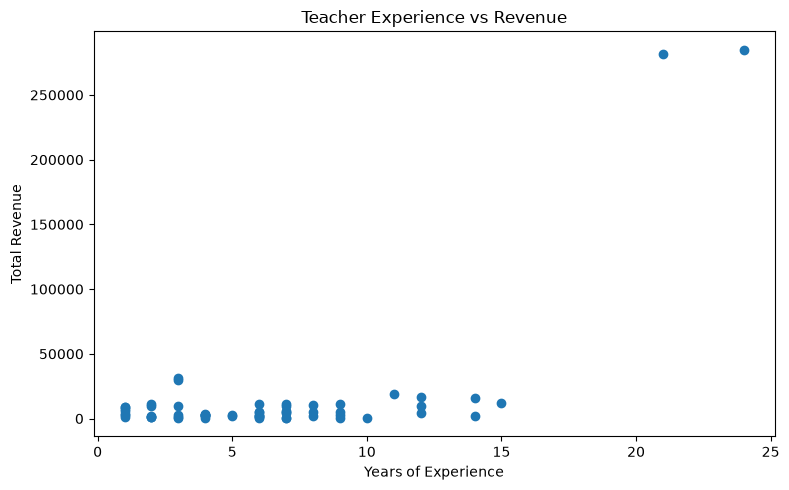

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    teacher_performance["YearsOfExperience"],
    teacher_performance["TotalRevenue"]
)

plt.title("Teacher Experience vs Revenue")
plt.xlabel("Years of Experience")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## PART B — Course Performance Analysis

## Course transaction performance

In [19]:
course_transactions = (
    performance_eda
    .groupby(["CourseID", "CourseName"])
    .size()
    .reset_index(name="TransactionCount")
    .sort_values("TransactionCount", ascending=False)
)

course_transactions.head(10)

,CourseID,CourseName,TransactionCount
20,CR00021,Data Analysis with Python,196
57,CR00058,Social Media Strategy,194
24,CR00025,Statistical Analysis,192
47,CR00048,AI Ethics,186
22,CR00023,Machine Learning Fundamentals,185
41,CR00042,Investment Strategies,183
42,CR00043,Corporate Finance,182
9,CR00010,3D Modeling,180
34,CR00035,Cyber Threat Intelligence,179
6,CR00007,UI/UX Design,178


## Course revenue performance 

In [20]:
course_revenue = (
    performance_eda
    .groupby(["CourseID", "CourseName"])["Amount"]
    .sum()
    .reset_index(name="TotalRevenue")
    .sort_values("TotalRevenue", ascending=False)
)

course_revenue.head(10)

,CourseID,CourseName,TotalRevenue
49,CR00050,Computer Vision,85416.60
11,CR00012,Business Strategy,84410.16
0,CR00001,Python Basics,77453.92
48,CR00049,Deep Learning,67728.13
33,CR00034,Data Encryption,59139.00
38,CR00039,Project Planning,57900.57
24,CR00025,Statistical Analysis,57517.44
39,CR00040,Leadership in Projects,57070.26
37,CR00038,Risk Management,54132.38
10,CR00011,Entrepreneurship 101,49229.02


## Build main course performance table

In [21]:
course_performance = (
    performance_eda
    .groupby(
        [
            "CourseID",
            "CourseName",
            "CourseCategory",
            "CourseType",
            "CourseLevel",
            "CoursePrice",
            "CourseDuration",
            "CourseRating",
            "TeacherID",
            "TeacherName"
        ]
    )
    .agg(
        TransactionCount=("TransactionID", "count"),
        TotalRevenue=("Amount", "sum"),
        AverageTransactionAmount=("Amount", "mean")
    )
    .reset_index()
)

In [22]:
course_performance.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherID,TeacherName,TransactionCount,TotalRevenue,AverageTransactionAmount
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TC00003,Amber Torres,2,944.56,472.28
1,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TC00005,David Williams,1,472.28,472.28
2,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TC00009,Alexander Tucker,2,944.56,472.28
3,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TC00010,Frances Sanchez,1,472.28,472.28
4,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,TC00015,John Armstrong,1,472.28,472.28


In [23]:
course_performance.sort_values(
    "TotalRevenue",
    ascending=False
).head(10)

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherID,TeacherName,TransactionCount,TotalRevenue,AverageTransactionAmount
605,CR00034,Data Encryption,Cybersecurity,Paid,Intermediate,394.26,47.44,1.35,TC00040,Kimberly Miller,92,36271.92,394.26
20,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,TC00042,Yolanda Levine,63,29753.64,472.28
236,CR00012,Business Strategy,Business,Paid,Advanced,487.92,36.01,3.64,TC00042,Yolanda Levine,58,28299.36,487.92
728,CR00050,Computer Vision,Artificial Intelligence,Paid,Beginner,490.90,7.55,4.55,TC00040,Kimberly Miller,54,26508.60,490.90
722,CR00049,Deep Learning,Artificial Intelligence,Paid,Intermediate,415.51,28.33,3.11,TC00042,Yolanda Levine,60,24930.60,415.51
730,CR00050,Computer Vision,Artificial Intelligence,Paid,Beginner,490.90,7.55,4.55,TC00042,Yolanda Levine,48,23563.20,490.90
235,CR00012,Business Strategy,Business,Paid,Advanced,487.92,36.01,3.64,TC00040,Kimberly Miller,45,21956.40,487.92
643,CR00039,Project Planning,Project Management,Paid,Advanced,346.71,3.42,1.23,TC00042,Yolanda Levine,63,21842.73,346.71
19,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,TC00040,Kimberly Miller,46,21724.88,472.28
293,CR00015,Leadership Essentials,Business,Paid,Beginner,285.05,34.78,1.96,TC00042,Yolanda Levine,68,19383.40,285.05


## Top 10 courses by demand

In [24]:
top_courses_demand = (
    course_performance
    .sort_values("TransactionCount", ascending=False)
    .head(10)
)

top_courses_demand

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherID,TeacherName,TransactionCount,TotalRevenue,AverageTransactionAmount
568,CR00030,Reinforcement Learning,Machine Learning,Free,Intermediate,0.00,38.49,1.73,TC00042,Yolanda Levine,107,0.00,0.00
614,CR00035,Cyber Threat Intelligence,Cybersecurity,Free,Beginner,0.00,42.59,4.94,TC00040,Kimberly Miller,103,0.00,0.00
489,CR00026,Intro to Machine Learning,Machine Learning,Free,Intermediate,0.00,47.70,4.73,TC00042,Yolanda Levine,100,0.00,0.00
526,CR00028,Deep Learning,Machine Learning,Paid,Advanced,0.78,44.96,3.89,TC00042,Yolanda Levine,99,77.22,0.78
596,CR00033,Cybersecurity Fundamentals,Cybersecurity,Free,Intermediate,0.00,48.25,3.93,TC00040,Kimberly Miller,97,0.00,0.00
587,CR00032,Ethical Hacking,Cybersecurity,Free,Advanced,0.00,16.74,2.38,TC00040,Kimberly Miller,93,0.00,0.00
605,CR00034,Data Encryption,Cybersecurity,Paid,Intermediate,394.26,47.44,1.35,TC00040,Kimberly Miller,92,36271.92,394.26
548,CR00029,Natural Language Processing,Machine Learning,Free,Beginner,0.00,16.33,1.13,TC00042,Yolanda Levine,92,0.00,0.00
506,CR00027,Neural Networks,Machine Learning,Free,Advanced,0.00,9.30,1.81,TC00042,Yolanda Levine,90,0.00,0.00
578,CR00031,Network Security,Cybersecurity,Free,Intermediate,0.00,26.52,1.91,TC00040,Kimberly Miller,90,0.00,0.00


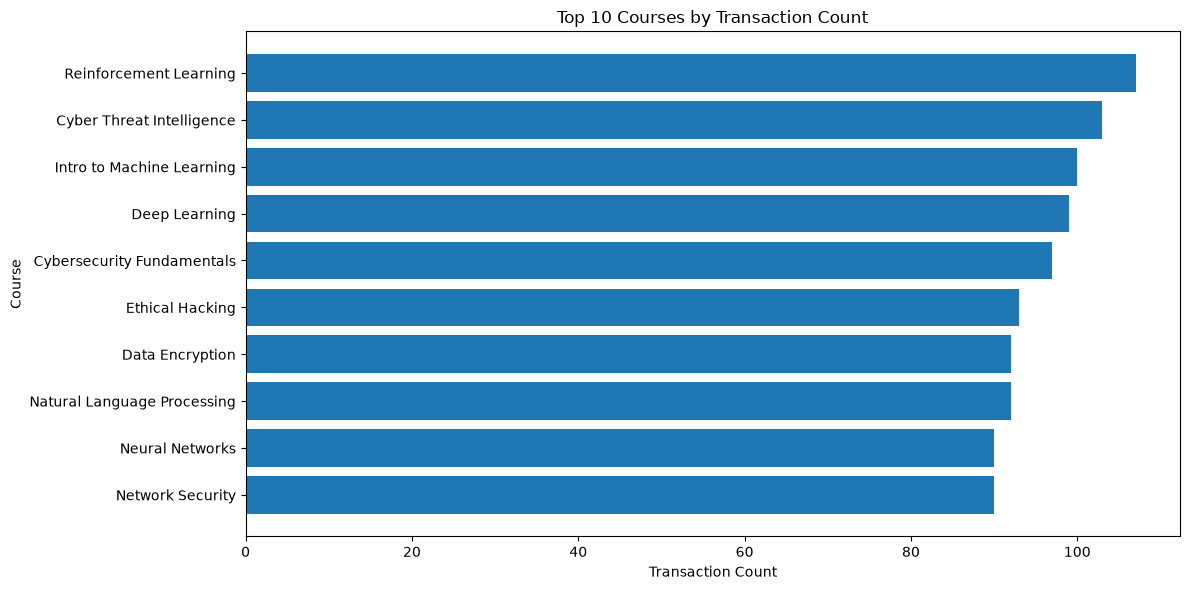

In [25]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_courses_demand["CourseName"],
    top_courses_demand["TransactionCount"]
)

plt.title("Top 10 Courses by Transaction Count")
plt.xlabel("Transaction Count")
plt.ylabel("Course")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Top 10 courses by revenue 

In [26]:
top_courses_revenue = (
    course_performance
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)

top_courses_revenue

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherID,TeacherName,TransactionCount,TotalRevenue,AverageTransactionAmount
605,CR00034,Data Encryption,Cybersecurity,Paid,Intermediate,394.26,47.44,1.35,TC00040,Kimberly Miller,92,36271.92,394.26
20,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,TC00042,Yolanda Levine,63,29753.64,472.28
236,CR00012,Business Strategy,Business,Paid,Advanced,487.92,36.01,3.64,TC00042,Yolanda Levine,58,28299.36,487.92
728,CR00050,Computer Vision,Artificial Intelligence,Paid,Beginner,490.90,7.55,4.55,TC00040,Kimberly Miller,54,26508.60,490.90
722,CR00049,Deep Learning,Artificial Intelligence,Paid,Intermediate,415.51,28.33,3.11,TC00042,Yolanda Levine,60,24930.60,415.51
730,CR00050,Computer Vision,Artificial Intelligence,Paid,Beginner,490.90,7.55,4.55,TC00042,Yolanda Levine,48,23563.20,490.90
235,CR00012,Business Strategy,Business,Paid,Advanced,487.92,36.01,3.64,TC00040,Kimberly Miller,45,21956.40,487.92
643,CR00039,Project Planning,Project Management,Paid,Advanced,346.71,3.42,1.23,TC00042,Yolanda Levine,63,21842.73,346.71
19,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,TC00040,Kimberly Miller,46,21724.88,472.28
293,CR00015,Leadership Essentials,Business,Paid,Beginner,285.05,34.78,1.96,TC00042,Yolanda Levine,68,19383.40,285.05


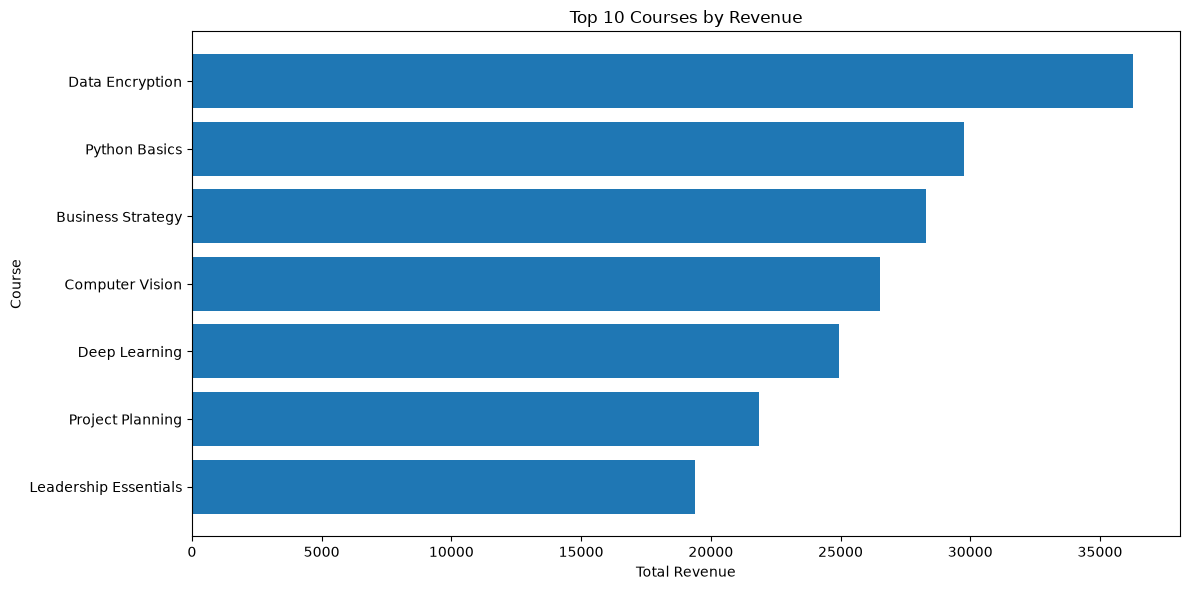

In [27]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_courses_revenue["CourseName"],
    top_courses_revenue["TotalRevenue"]
)

plt.title("Top 10 Courses by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Course")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Course rating vs demand

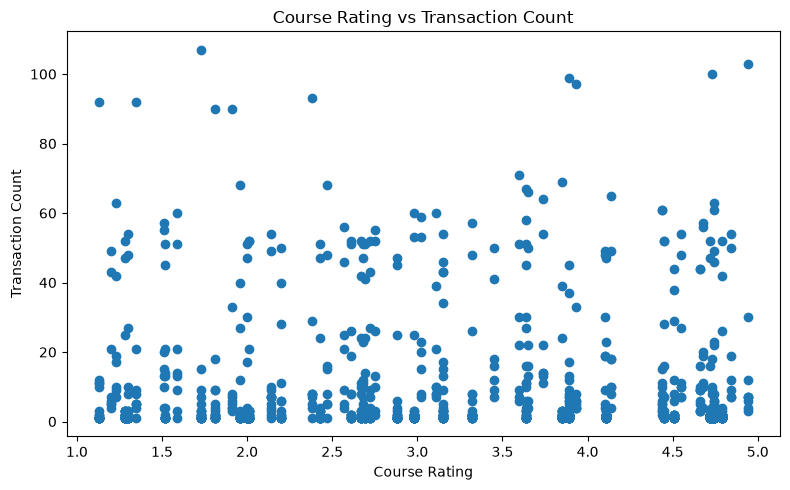

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    course_performance["CourseRating"],
    course_performance["TransactionCount"]
)

plt.title("Course Rating vs Transaction Count")
plt.xlabel("Course Rating")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

## Course rating vs revenue 

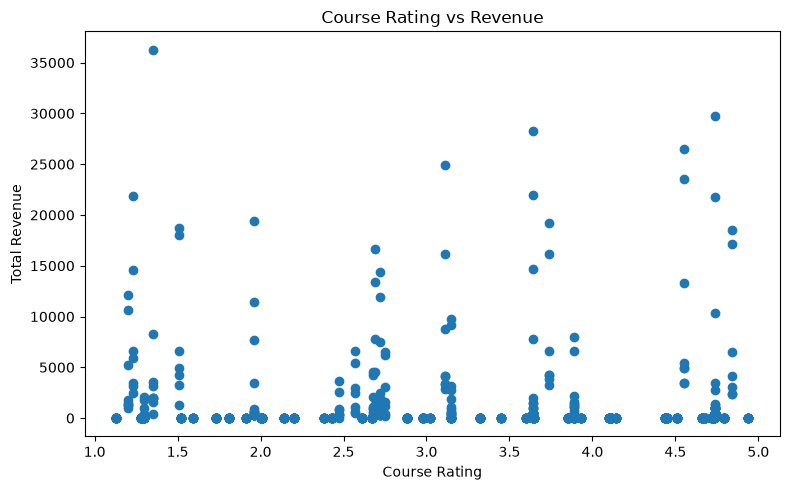

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(
    course_performance["CourseRating"],
    course_performance["TotalRevenue"]
)

plt.title("Course Rating vs Revenue")
plt.xlabel("Course Rating")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## PART C — Category Performance

## Course category performance 

In [30]:
category_performance = (
    performance_eda
    .groupby("CourseCategory")
    .agg(
        TransactionCount=("TransactionID", "count"),
        TotalRevenue=("Amount", "sum"),
        AverageRevenue=("Amount", "mean"),
        CourseCount=("CourseID", "nunique")
    )
    .reset_index()
    .sort_values("TotalRevenue", ascending=False)
)

category_performance

,CourseCategory,TransactionCount,TotalRevenue,AverageRevenue,CourseCount
0,Artificial Intelligence,829,202750.67,244.572581,5
1,Business,833,181527.58,217.920264,5
10,Project Management,829,169103.21,203.984572,5
9,Programming,806,77453.92,96.096675,5
3,Data Science,916,77052.32,84.118253,5
2,Cybersecurity,819,59139.00,72.208791,5
5,Digital Marketing,808,56261.32,69.630347,5
4,Design,827,43113.72,52.132672,5
6,Finance,864,28106.20,32.530324,5
11,Web Development,844,16682.15,19.765581,5


## Category revenue chart

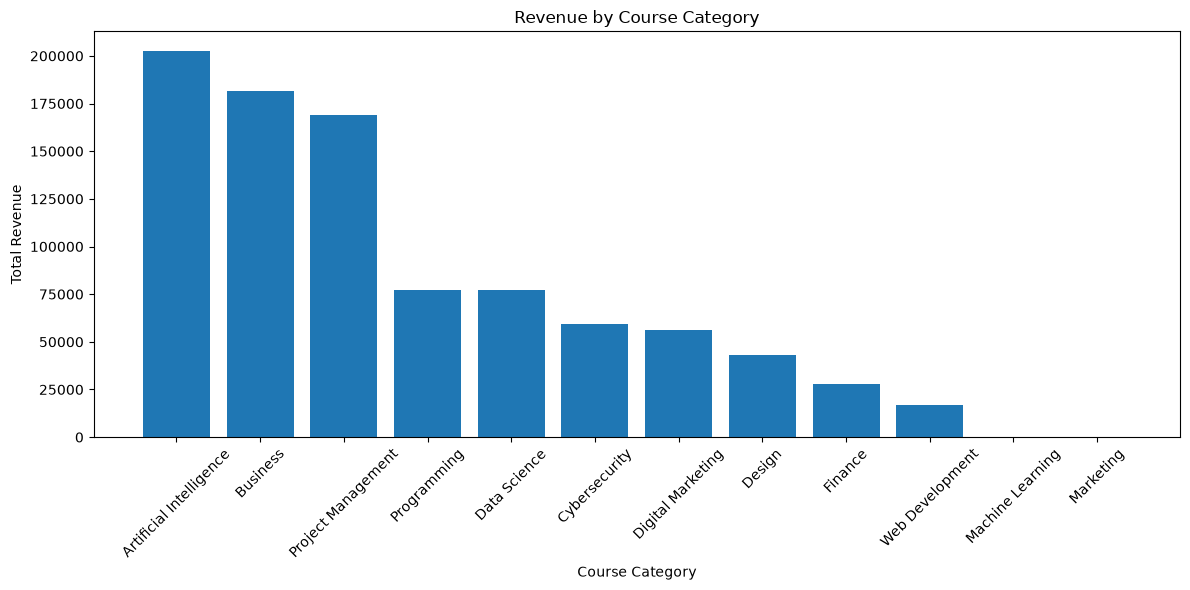

In [31]:
plt.figure(figsize=(12, 6))

plt.bar(
    category_performance["CourseCategory"],
    category_performance["TotalRevenue"]
)

plt.title("Revenue by Course Category")
plt.xlabel("Course Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Category transaction chart

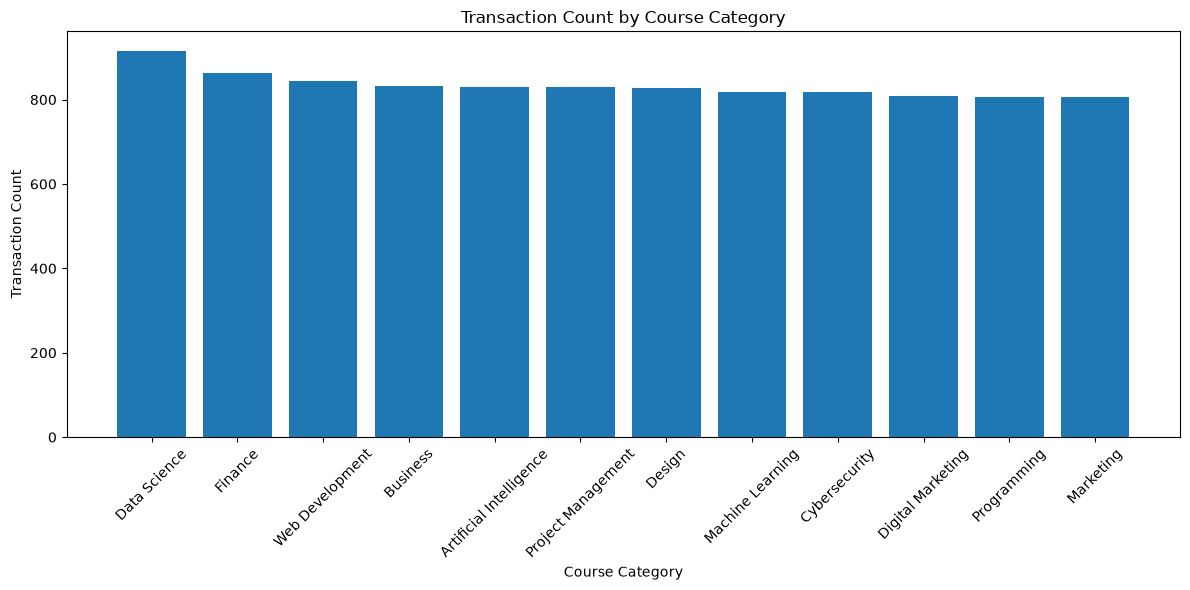

In [32]:
category_demand = (
    category_performance
    .sort_values("TransactionCount", ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    category_demand["CourseCategory"],
    category_demand["TransactionCount"]
)

plt.title("Transaction Count by Course Category")
plt.xlabel("Course Category")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## PART D — High-Demand vs High-Revenue Courses

In [33]:
transaction_median = course_performance["TransactionCount"].median()
revenue_median = course_performance["TotalRevenue"].median()

transaction_median, revenue_median

(np.float64(2.0), np.float64(0.0))

In [34]:
course_performance["PerformanceSegment"] = np.select(
    [
        (course_performance["TransactionCount"] >= transaction_median) &
        (course_performance["TotalRevenue"] >= revenue_median),

        (course_performance["TransactionCount"] >= transaction_median) &
        (course_performance["TotalRevenue"] < revenue_median),

        (course_performance["TransactionCount"] < transaction_median) &
        (course_performance["TotalRevenue"] >= revenue_median)
    ],
    [
        "High Demand - High Revenue",
        "High Demand - Low Revenue",
        "Low Demand - High Revenue"
    ],
    default="Low Demand - Low Revenue"
)

In [35]:
course_performance[
    [
        "CourseName",
        "TransactionCount",
        "TotalRevenue",
        "PerformanceSegment"
    ]
].head(20)

,CourseName,TransactionCount,TotalRevenue,PerformanceSegment
0,Python Basics,2,944.56,High Demand - High Revenue
1,Python Basics,1,472.28,Low Demand - High Revenue
2,Python Basics,2,944.56,High Demand - High Revenue
3,Python Basics,1,472.28,Low Demand - High Revenue
4,Python Basics,1,472.28,Low Demand - High Revenue
5,Python Basics,2,944.56,High Demand - High Revenue
6,Python Basics,3,1416.84,High Demand - High Revenue
7,Python Basics,1,472.28,Low Demand - High Revenue
8,Python Basics,2,944.56,High Demand - High Revenue
9,Python Basics,2,944.56,High Demand - High Revenue


## Visualize demand vs revenue

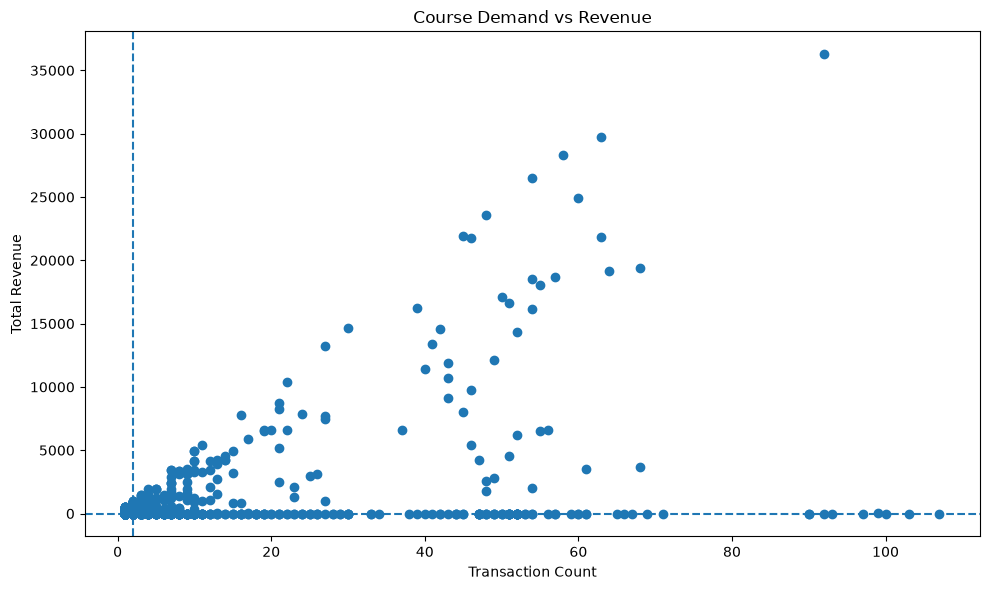

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    course_performance["TransactionCount"],
    course_performance["TotalRevenue"]
)

plt.axvline(transaction_median, linestyle="--")
plt.axhline(revenue_median, linestyle="--")

plt.title("Course Demand vs Revenue")
plt.xlabel("Transaction Count")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## PART E — Teacher-Course Relationship

## Teacher course portfolio

In [37]:
teacher_course_portfolio = (
    performance_eda
    .groupby(
        ["TeacherID", "TeacherName"]
    )
    .agg(
        CourseCount=("CourseID", "nunique"),
        TransactionCount=("TransactionID", "count"),
        TotalRevenue=("Amount", "sum"),
        TeacherRating=("TeacherRating", "first"),
        YearsOfExperience=("YearsOfExperience", "first")
    )
    .reset_index()
)

In [38]:
teacher_course_portfolio.sort_values(
    "TotalRevenue",
    ascending=False
).head(10)

,TeacherID,TeacherName,CourseCount,TransactionCount,TotalRevenue,TeacherRating,YearsOfExperience
39,TC00040,Kimberly Miller,55,3025,284933.49,4.58,24
41,TC00042,Yolanda Levine,55,3061,281719.73,4.97,21
27,TC00028,Timothy Bailey,16,161,31102.99,1.06,3
26,TC00027,Laurie Michael,13,133,29723.74,1.55,3
17,TC00018,Kari Pierce,8,93,18621.84,4.28,11
51,TC00052,Susan Johnson,19,97,16773.24,3.43,12
59,TC00060,Benjamin Gray,15,92,15537.36,3.32,14
7,TC00008,Steven Walker,9,133,11851.45,3.54,15
53,TC00054,Shelby Patrick,9,46,11551.14,4.28,7
28,TC00029,David Webb,18,66,11323.98,3.10,2


## Revenue per course for teachers

In [39]:
teacher_course_portfolio["RevenuePerCourse"] = (
    teacher_course_portfolio["TotalRevenue"] /
    teacher_course_portfolio["CourseCount"]
)

In [40]:
teacher_course_portfolio.sort_values(
    "RevenuePerCourse",
    ascending=False
).head(10)

,TeacherID,TeacherName,CourseCount,TransactionCount,TotalRevenue,TeacherRating,YearsOfExperience,RevenuePerCourse
39,TC00040,Kimberly Miller,55,3025,284933.49,4.58,24,5180.608909
41,TC00042,Yolanda Levine,55,3061,281719.73,4.97,21,5122.176909
17,TC00018,Kari Pierce,8,93,18621.84,4.28,11,2327.730000
26,TC00027,Laurie Michael,13,133,29723.74,1.55,3,2286.441538
27,TC00028,Timothy Bailey,16,161,31102.99,1.06,3,1943.936875
40,TC00041,Kevin Simpson,7,44,9785.05,3.55,7,1397.864286
55,TC00056,Alexis Everett,8,123,11163.13,3.95,9,1395.391250
7,TC00008,Steven Walker,9,133,11851.45,3.54,15,1316.827778
53,TC00054,Shelby Patrick,9,46,11551.14,4.28,7,1283.460000
32,TC00033,Wesley Garcia,8,137,9539.04,4.04,12,1192.380000


## PART F — Identify Top Performers

## Top Teachers

In [41]:
top_teachers = (
    teacher_performance
    .sort_values(
        ["TotalRevenue", "TransactionCount"],
        ascending=False
    )
    .head(10)
)

top_teachers

,TeacherID,TeacherName,Expertise,YearsOfExperience,TeacherRating,TransactionCount,TotalRevenue,AverageTransactionAmount,CourseCount
39,TC00040,Kimberly Miller,Cybersecurity,24,4.58,3025,284933.49,94.192889,55
41,TC00042,Yolanda Levine,Machine Learning,21,4.97,3061,281719.73,92.035194,55
27,TC00028,Timothy Bailey,Business,3,1.06,161,31102.99,193.186273,16
26,TC00027,Laurie Michael,Artificial Intelligence,3,1.55,133,29723.74,223.486767,13
17,TC00018,Kari Pierce,Project Management,11,4.28,93,18621.84,200.234839,8
51,TC00052,Susan Johnson,Business,12,3.43,97,16773.24,172.920000,19
59,TC00060,Benjamin Gray,Project Management,14,3.32,92,15537.36,168.884348,15
7,TC00008,Steven Walker,Data Science,15,3.54,133,11851.45,89.108647,9
53,TC00054,Shelby Patrick,Artificial Intelligence,7,4.28,46,11551.14,251.111739,9
28,TC00029,David Webb,Artificial Intelligence,2,3.10,66,11323.98,171.575455,18


## Top Courses

In [42]:
top_courses = (
    course_performance
    .sort_values(
        ["TotalRevenue", "TransactionCount"],
        ascending=False
    )
    .head(10)
)

top_courses

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherID,TeacherName,TransactionCount,TotalRevenue,AverageTransactionAmount,PerformanceSegment
605,CR00034,Data Encryption,Cybersecurity,Paid,Intermediate,394.26,47.44,1.35,TC00040,Kimberly Miller,92,36271.92,394.26,High Demand - High Revenue
20,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,TC00042,Yolanda Levine,63,29753.64,472.28,High Demand - High Revenue
236,CR00012,Business Strategy,Business,Paid,Advanced,487.92,36.01,3.64,TC00042,Yolanda Levine,58,28299.36,487.92,High Demand - High Revenue
728,CR00050,Computer Vision,Artificial Intelligence,Paid,Beginner,490.90,7.55,4.55,TC00040,Kimberly Miller,54,26508.60,490.90,High Demand - High Revenue
722,CR00049,Deep Learning,Artificial Intelligence,Paid,Intermediate,415.51,28.33,3.11,TC00042,Yolanda Levine,60,24930.60,415.51,High Demand - High Revenue
730,CR00050,Computer Vision,Artificial Intelligence,Paid,Beginner,490.90,7.55,4.55,TC00042,Yolanda Levine,48,23563.20,490.90,High Demand - High Revenue
235,CR00012,Business Strategy,Business,Paid,Advanced,487.92,36.01,3.64,TC00040,Kimberly Miller,45,21956.40,487.92,High Demand - High Revenue
643,CR00039,Project Planning,Project Management,Paid,Advanced,346.71,3.42,1.23,TC00042,Yolanda Levine,63,21842.73,346.71,High Demand - High Revenue
19,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,TC00040,Kimberly Miller,46,21724.88,472.28,High Demand - High Revenue
293,CR00015,Leadership Essentials,Business,Paid,Beginner,285.05,34.78,1.96,TC00042,Yolanda Levine,68,19383.40,285.05,High Demand - High Revenue


## PART G — Final Validation

In [43]:
print("Performance rows:", performance_eda.shape[0])
print("Performance columns:", performance_eda.shape[1])
print("Missing values:", performance_eda.isnull().sum().sum())
print("Duplicate rows:", performance_eda.duplicated().sum())

Performance rows: 10000
Performance columns: 29
Missing values: 0
Duplicate rows: 0


## Saving Work

In [44]:
from pathlib import Path

eda_folder = Path(
    r"D:\Data Analytics Project\EduPro_Predictive_Modeling\data\eda_data"
)

eda_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [45]:
teacher_course_file_path = (
    eda_folder / "EduPro_Teacher_Course_Performance_EDA.xlsx"
)

teacher_course_file_path

WindowsPath('D:/Data Analytics Project/EduPro_Predictive_Modeling/data/eda_data/EduPro_Teacher_Course_Performance_EDA.xlsx')

## Saving the important Day 6 tables

In [46]:
with pd.ExcelWriter(
    teacher_course_file_path,
    engine="openpyxl"
) as writer:

    teacher_performance.to_excel(
        writer,
        sheet_name="Teacher_Performance",
        index=False
    )

    top_teachers_transactions.to_excel(
        writer,
        sheet_name="Top_Teachers_Demand",
        index=False
    )

    top_teachers_revenue.to_excel(
        writer,
        sheet_name="Top_Teachers_Revenue",
        index=False
    )

    teacher_course_portfolio.to_excel(
        writer,
        sheet_name="Teacher_Portfolio",
        index=False
    )

    course_performance.to_excel(
        writer,
        sheet_name="Course_Performance",
        index=False
    )

    top_courses_demand.to_excel(
        writer,
        sheet_name="Top_Courses_Demand",
        index=False
    )

    top_courses_revenue.to_excel(
        writer,
        sheet_name="Top_Courses_Revenue",
        index=False
    )

    category_performance.to_excel(
        writer,
        sheet_name="Category_Performance",
        index=False
    )

    course_performance[
        [
            "CourseID",
            "CourseName",
            "TransactionCount",
            "TotalRevenue",
            "PerformanceSegment"
        ]
    ].to_excel(
        writer,
        sheet_name="Course_Segments",
        index=False
    )

In [47]:
print(
    f"Teacher & Course Performance EDA saved at:\n"
    f"{teacher_course_file_path}"
)

Teacher & Course Performance EDA saved at:
D:\Data Analytics Project\EduPro_Predictive_Modeling\data\eda_data\EduPro_Teacher_Course_Performance_EDA.xlsx
